In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LIBRARIES

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torchvision.models import MobileNet_V2_Weights
import matplotlib.pyplot as plt

INPUTS

In [35]:
IMG_HEIGHT =224
IMG_WIDTH = 224
IMG_CHANNELS= 3
CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [36]:
transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir="/content/drive/MyDrive/flower_images/train"
val_dir ="/content/drive/MyDrive/flower_images/val"

train_data = datasets.ImageFolder(root=train_dir, transform=transform)
val_data= datasets.ImageFolder(root=val_dir, transform= val_transform)

train_dataset = DataLoader(train_data, batch_size =16, shuffle=True)
val_dataset = DataLoader(val_data, batch_size =16)

NETWORK ARCHITECTURE

In [37]:
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad=False

model.classifier[-1]= nn.Linear(model.last_channel, len(CLASS_NAMES))

for param in model.classifier[-1].parameters():
    param.requires_grad =True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [39]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss=[]
    train_acc=[]
    val_loss=[]
    val_acc=[]
    for epoch in range(epochs):
        model.train()
        correct_preds=0
        total_loss =0
        total_samples=0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct_preds += (preds==labels).sum().item()
            total_loss +=loss.item()
            total_samples += labels.size(0)

        acc = correct_preds/total_samples
        train_loss.append(total_loss)
        train_acc.append(acc)
        print(f"Epoch {epoch+1}: Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")

        model.eval()
        with torch.no_grad():
            eval_preds =0
            eval_loss = 0
            eval_samples=0
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                eval_preds += (preds==labels).sum().item()
                eval_loss  += loss.item()
                eval_samples += labels.size(0)

            eval_acc = eval_preds/eval_samples
            val_loss.append(eval_loss)
            val_acc.append(eval_acc)
            print(f"Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")
    return train_loss, train_acc, val_loss, val_acc


TRAINING

In [40]:
EPOCHS = 10
train_loss, train_acc, val_loss, val_acc =  train_model(model, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch 1: Loss: 169.1947, Accuracy: 0.7237
Validation Loss: 32.9764, Validation Accuracy: 0.8600
Epoch 2: Loss: 104.5403, Accuracy: 0.8240
Validation Loss: 25.3105, Validation Accuracy: 0.8790
Epoch 3: Loss: 88.2491, Accuracy: 0.8463
Validation Loss: 22.6904, Validation Accuracy: 0.8980
Epoch 4: Loss: 80.1974, Accuracy: 0.8520
Validation Loss: 21.3059, Validation Accuracy: 0.8910
Epoch 5: Loss: 76.8664, Accuracy: 0.8560
Validation Loss: 19.9609, Validation Accuracy: 0.9070
Epoch 6: Loss: 72.7562, Accuracy: 0.8697
Validation Loss: 18.8807, Validation Accuracy: 0.9000
Epoch 7: Loss: 70.6887, Accuracy: 0.8703
Validation Loss: 19.1098, Validation Accuracy: 0.9010
Epoch 8: Loss: 67.1717, Accuracy: 0.8777
Validation Loss: 18.1534, Validation Accuracy: 0.9090
Epoch 9: Loss: 64.4224, Accuracy: 0.8827
Validation Loss: 17.6917, Validation Accuracy: 0.9080
Epoch 10: Loss: 64.4006, Accuracy: 0.8763
Validation Loss: 17.1640, Validation Accuracy: 0.9150


PLOTTING

<function matplotlib.pyplot.show(close=None, block=None)>

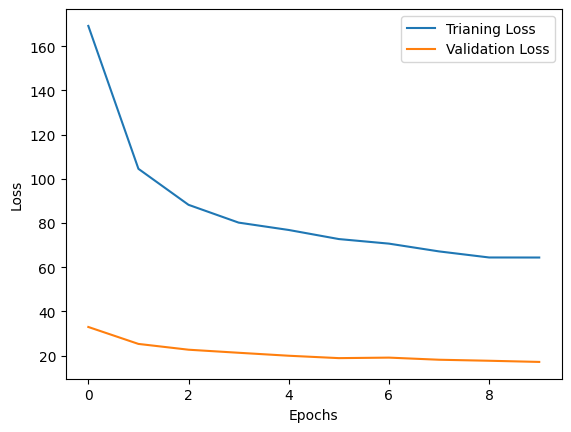

In [41]:
plt.plot(train_loss, label="Trianing Loss")
plt.plot(val_loss, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

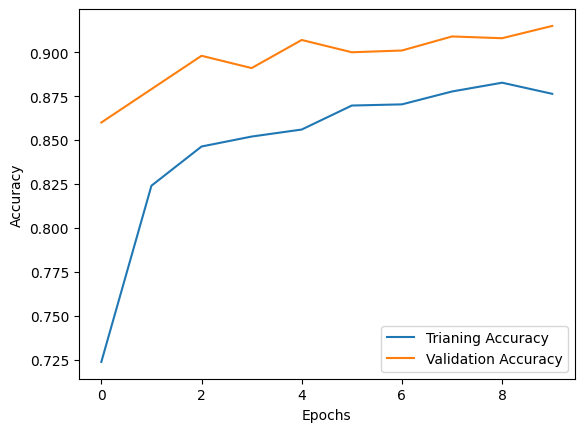

In [42]:
plt.plot(train_acc, label="Trianing Accuracy")
plt.plot(val_acc, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show